# Estimación de cierre de demanda

Este notebook explica paso a paso cómo estimo en cuánto va a cerrar la demanda de
cada producto-país antes de que termine el mes, partiendo de las órdenes que ya
llevo y de cómo se comportó la demanda en meses pasados.

La lógica está también en los scripts de `src/` (`modelo_cierre.py`, `backtest.py`);
aquí la desarmo para que se vea el razonamiento.

> Los datos son **sintéticos**, generados por `src/generar_datos.py`. No vienen de
> ninguna empresa; solo imitan la forma que tienen estos datos en la vida real.

In [1]:
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
ANIO, MES = 2026, 6
DIA_HOY = 12
MESES_HISTORIA = [3, 4, 5]

## 1. El problema

Estamos a día 12 de junio. Para cada combinación país + SKU llevo cierta cantidad de
unidades confirmadas, y tengo un forecast de todo el mes. La pregunta es:
**¿en cuánto voy a cerrar?**

Lo fácil sería suponer que lo que falta del mes llega parejo (proporción lineal: si
voy en el día 12 de 30, debería llevar el 40%). Pero eso casi nunca es cierto: hay
productos que se piden mucho a inicio de mes y otros que cargan al final. Por eso uso
la **historia** para saber qué fracción del mes suele haber llegado a estas alturas.

In [2]:
# Cargar las órdenes de un mes
def cargar_ordenes(mes, parcial=False):
    sufijo = "_parcial" if parcial else ""
    df = pd.read_excel(DATA_DIR / f"ordenes_{ANIO}_{mes:02d}{sufijo}.xlsx")
    df["fecha_entrega"] = pd.to_datetime(df["fecha_entrega"])
    df["dia"] = df["fecha_entrega"].dt.day
    df["llave"] = df["pais"] + "_" + df["sku"]
    return df

ejemplo = cargar_ordenes(3)
ejemplo.head()

,fecha_entrega,pais,sku,descripcion,cantidad,dia,llave
0,2026-03-01,Mexico,SKU-001,Producto generico 001,13,1,Mexico_SKU-001
1,2026-03-02,Mexico,SKU-001,Producto generico 001,21,2,Mexico_SKU-001
2,2026-03-03,Mexico,SKU-001,Producto generico 001,23,3,Mexico_SKU-001
3,2026-03-04,Mexico,SKU-001,Producto generico 001,23,4,Mexico_SKU-001
4,2026-03-05,Mexico,SKU-001,Producto generico 001,23,5,Mexico_SKU-001


## 2. La curva de acumulado (el corazón del modelo)

Para cada mes de historia y cada llave calculo qué proporción del total mensual llegó
cada día. Luego hago el acumulado: al día 1 llevo X%, al día 2 X+Y%, etc. Así obtengo
una curva que me dice, para cualquier día, qué fracción del mes "ya debería haber
pasado".

Promedio esa curva sobre los 3 meses de historia.

In [3]:
def perfil_de_un_mes(df):
    por_dia = df.groupby(["llave", "dia"])["cantidad"].sum().reset_index()
    total = (df.groupby("llave")["cantidad"].sum()
             .reset_index().rename(columns={"cantidad": "total_mes"}))
    perfil = por_dia.merge(total, on="llave")
    perfil["proporcion"] = perfil["cantidad"] / perfil["total_mes"]
    return perfil[["llave", "dia", "proporcion"]]

perfiles = [perfil_de_un_mes(cargar_ordenes(m)) for m in MESES_HISTORIA]
todos = pd.concat(perfiles, ignore_index=True)

# Promedio entre meses (sum/n para que los días sin venta cuenten como 0)
perfil = todos.groupby(["llave", "dia"])["proporcion"].sum().reset_index()
perfil["proporcion"] = perfil["proporcion"] / len(MESES_HISTORIA)

# Acumulado normalizado (cada llave llega a 1.0)
perfil = perfil.sort_values(["llave", "dia"]).reset_index(drop=True)
perfil["acum"] = perfil.groupby("llave")["proporcion"].cumsum()
maximos = (perfil.groupby("llave")["acum"].max()
           .reset_index().rename(columns={"acum": "acum_max"}))
perfil = perfil.merge(maximos, on="llave")
perfil["acum_norm"] = perfil["acum"] / perfil["acum_max"]
perfil.head()

,llave,dia,proporcion,acum,acum_max,acum_norm
0,Brasil_SKU-001,1,0.008014,0.008014,1.0,0.008014
1,Brasil_SKU-001,2,0.012835,0.020849,1.0,0.020849
2,Brasil_SKU-001,3,0.012352,0.033201,1.0,0.033201
3,Brasil_SKU-001,4,0.016347,0.049548,1.0,0.049548
4,Brasil_SKU-001,5,0.019417,0.068965,1.0,0.068965


Para que se vea la idea, dibujo la curva de acumulado de unas cuantas llaves.
Una recta diagonal sería el supuesto lineal (demanda pareja); lo interesante es cómo
las curvas reales se separan de esa diagonal.

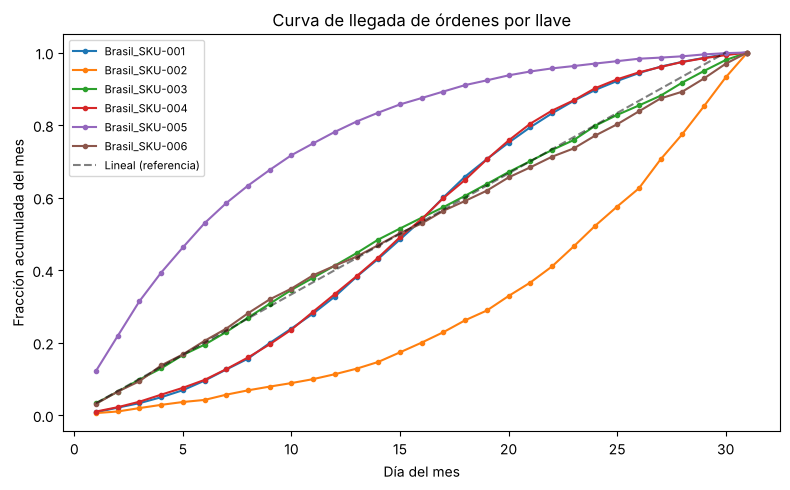

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
muestra = perfil["llave"].drop_duplicates().head(6)
for llave in muestra:
    sub = perfil[perfil["llave"] == llave]
    ax.plot(sub["dia"], sub["acum_norm"], marker="o", ms=3, label=llave)

dias = range(1, 31)
ax.plot(dias, [d / 30 for d in dias], "k--", alpha=0.5, label="Lineal (referencia)")
ax.set_xlabel("Día del mes")
ax.set_ylabel("Fracción acumulada del mes")
ax.set_title("Curva de llegada de órdenes por llave")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Avance real y proyección

Ahora cargo el mes en curso (cortado al día 12) y el forecast. Para cada llave:

- **avance_vs_fcst** = unidades que llevo / forecast
- **frac_historica** = qué fracción del mes ya pasó, según la curva
- **cierre estimado %** = avance + (1 − frac_historica)

En palabras: a lo que ya llevo le sumo lo que, según la historia, todavía falta por
llegar.

In [5]:
df_curso = cargar_ordenes(MES, parcial=True)
fcst = pd.read_excel(DATA_DIR / f"forecast_{ANIO}_{MES:02d}.xlsx")
fcst["llave"] = fcst["pais"] + "_" + fcst["sku"]

avance = (df_curso[df_curso["dia"] <= DIA_HOY]
          .groupby("llave")["cantidad"].sum()
          .reset_index().rename(columns={"cantidad": "uds_observadas"}))

res = fcst.merge(avance, on="llave", how="left")
res["uds_observadas"] = res["uds_observadas"].fillna(0)
res["avance_vs_fcst"] = res["uds_observadas"] / res["forecast"]

# fracción del mes según la curva, hasta el día de hoy
frac = (perfil[perfil["dia"] <= DIA_HOY]
        .sort_values(["llave", "dia"]).groupby("llave")["acum_norm"].last()
        .reset_index().rename(columns={"acum_norm": "frac_historica"}))
res = res.merge(frac, on="llave", how="left")
res["frac_historica"] = res["frac_historica"].fillna(DIA_HOY / 30)

res["cierre_pct"] = res["avance_vs_fcst"] + (1 - res["frac_historica"])
res["uds_cierre_est"] = res["cierre_pct"] * res["forecast"]
res[["llave", "forecast", "uds_observadas", "avance_vs_fcst",
     "frac_historica", "cierre_pct", "uds_cierre_est"]].head()

,llave,forecast,uds_observadas,avance_vs_fcst,frac_historica,cierre_pct,uds_cierre_est
0,Mexico_SKU-001,3785,770,0.203435,0.336207,0.867227,3282.455822
1,Guatemala_SKU-001,2770,360,0.129964,0.349764,0.780200,2161.154637
2,Panama_SKU-001,2512,610,0.242834,0.358705,0.884129,2220.932057
3,Colombia_SKU-001,728,640,0.879121,0.344373,1.534748,1117.296627
4,Ecuador_SKU-001,949,472,0.497366,0.346770,1.150595,1091.914870


## 4. Semáforo

Para que sea accionable, clasifico cada llave: si el cierre estimado supera el 120%
del forecast es **sobre demanda** (riesgo de quedarme corto de inventario), si baja
de 80% es **baja demanda** (riesgo de sobrestock), y en medio está **en rango**.

In [6]:
def semaforo(pct, hay):
    if not hay: return "Sin ordenes"
    if pct > 1.20: return "Sobre demanda"
    if pct < 0.80: return "Baja demanda"
    return "En rango"

res["semaforo_cierre"] = [semaforo(p, o > 0)
                          for p, o in zip(res["cierre_pct"], res["uds_observadas"])]
res["semaforo_cierre"].value_counts()

semaforo_cierre
En rango         94
Sobre demanda    38
Baja demanda     18
Name: count, dtype: int64

## 5. ¿Qué tan bien funciona? (backtest)

Como estos datos son simulados, tengo el cierre real del mes, que en la vida real
todavía no existiría. Me paro en varios días de corte, proyecto el cierre, y comparo
contra el real. Espero que el error baje conforme avanza el mes.

In [7]:
import importlib, sys
sys.path.insert(0, "src")
import modelo_cierre as mc
import backtest as bt
importlib.reload(mc); importlib.reload(bt)

resumen_bt = bt.correr_backtest()
resumen_bt

Backtest — proyección de cierre vs cierre real

 Dia corte | MAPE por llave |  Error global |  Avance real
------------------------------------------------------------


         5 |         58.2% |         0.8% |       14.6%


        10 |         48.1% |         1.6% |       30.2%


        15 |         36.1% |         2.1% |       48.0%


        20 |         23.9% |         2.2% |       65.8%

Lectura rápida:
- El error global (sobre el total de unidades) es el que más importa
  para planeación agregada; el MAPE por llave es más duro porque castiga
  mucho a los SKUs chicos.
- Conforme avanza el mes y hay más órdenes confirmadas, el error baja.


,dia_corte,mape_llave,error_global,avance_real
0,5,0.582186,0.008384,0.145667
1,10,0.480799,0.015553,0.301503
2,15,0.361479,0.021344,0.479633
3,20,0.239032,0.021766,0.657729


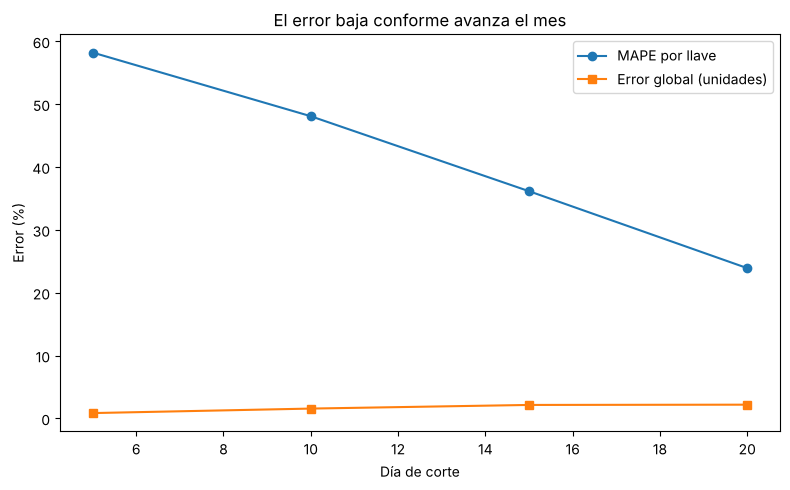

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(resumen_bt["dia_corte"], resumen_bt["mape_llave"] * 100,
        marker="o", label="MAPE por llave")
ax.plot(resumen_bt["dia_corte"], resumen_bt["error_global"] * 100,
        marker="s", label="Error global (unidades)")
ax.set_xlabel("Día de corte")
ax.set_ylabel("Error (%)")
ax.set_title("El error baja conforme avanza el mes")
ax.legend()
plt.tight_layout()
plt.show()

## Qué me llevo de esto

- En **agregado** el modelo es muy bueno: el error global sobre el total de unidades
  se queda en 1–2% casi todo el mes. Para planear compras a nivel país/región sirve
  bien desde temprano.
- Por **SKU individual** el error arranca alto (los productos chicos son ruidosos) y
  baja a la mitad conforme avanza el mes y hay más órdenes confirmadas.
- La principal **limitación**: el modelo supone que un avance alto = más demanda. Pero
  si un cliente simplemente *adelantó* compras, el modelo lo lee como sobre demanda
  cuando en realidad va a cerrar igual. Distinguir "más demanda" de "demanda adelantada"
  es la siguiente mejora pendiente.